# 08 — EPC C reachability and retrofit cost analysis

**Research question:** For London social rented homes below EPC C (score < 69):
- Which can reach C by 2030 given the assessor's listed recommendations?
- What is the retrofit cost burden per borough, and how many properties are likely to need the £10k exemption?
- Which improvement measures deliver the most EPC points per pound?

**Method:**
1. Use the EPC assessor's `potential_energy_efficiency ≥ 69` as the reachability flag (professional judgement, treated as ground truth).
2. A RandomForest predicts total achievable EPC uplift (potential − current) from recommendation presence + property characteristics.
3. SHAP decomposes each prediction into per-feature contributions, producing a data-driven ranking of which improvement types are most associated with achievable uplift — stratified by construction age band.
4. Combine SHAP with RdSAP indicative costs to produce a £/EPC-point cost-effectiveness ranking.
5. A greedy subset selector estimates the cheapest cost-effective set of measures per property (experimental — see methodology note in §6).

**April 2030 deadline:** All social rented homes in England must reach EPC C. Properties over £10,000 to retrofit may qualify for the government exemption cap.

In [1]:
import glob
import re
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
import shap

pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 20)

BRONZE_EPC = '../data/bronze/epc_raw'
GOLD       = '../data/gold'
EPC_C      = 69        # minimum score for EPC band C
EXEMPT_CAP = 10_000    # £10k government exemption cap
SHAP_N     = 5_000     # SHAP sample size (speed vs precision tradeoff)

# 12 EPC age bands → 5 interpretable groups (MHCLG policy vocabulary)
AGE_GROUPS = {
    'England and Wales: before 1900': 'Pre-1919',
    'England and Wales: 1900-1929':   'Pre-1919',
    'England and Wales: 1930-1949':   '1930–1949',
    'England and Wales: 1950-1966':   '1950–1966',
    'England and Wales: 1967-1975':   '1967–1983',
    'England and Wales: 1976-1982':   '1967–1983',
    'England and Wales: 1983-1990':   '1967–1983',
    'England and Wales: 1991-1995':   '1991–2006',
    'England and Wales: 1996-2002':   '1991–2006',
    'England and Wales: 2003-2006':   '1991–2006',
    'England and Wales: 2007-2011':   '2007+',
    'England and Wales: 2012 onwards': '2007+',
}
AGE_ORDER = ['Pre-1919', '1930–1949', '1950–1966', '1967–1983', '1991–2006', '2007+']

print('Libraries loaded')

Libraries loaded


## 1. Load London social rented certificates

In [2]:
cert_files = sorted(glob.glob(f'{BRONZE_EPC}/certificates-*.csv'))
print(f'Certificate files: {len(cert_files)}')

# Load extra dedup keys (uprn, postcode, address1, inspection_date) alongside analysis columns.
CERT_COLS = [
    'certificate_number', 'local_authority_label', 'tenure', 'region',
    'current_energy_efficiency', 'potential_energy_efficiency',
    'construction_age_band', 'property_type',
    'uprn', 'postcode', 'address1', 'inspection_date',
]

chunks = []
for f in cert_files:
    df = pd.read_csv(f, usecols=CERT_COLS, dtype=str, low_memory=False)
    df = df[
        (df['region'] == 'E12000007') &
        (df['tenure'].str.upper().isin(['RENTAL (SOCIAL)', 'SOCIAL RENTED', 'RENTED (SOCIAL)']))
    ]
    chunks.append(df)

certs_raw = pd.concat(chunks, ignore_index=True)
n_certs_raw = len(certs_raw)

# ── Deduplicate to one row per property, keeping the latest inspection ─────────
# Same strategy as nb03/src/ingest_epc: UPRN as primary key, postcode+address1 as fallback,
# order by inspection_date desc so the newest cert wins.
certs_raw['dedup_key'] = certs_raw['uprn'].where(
    certs_raw['uprn'].notna() & (certs_raw['uprn'].str.strip() != ''),
    certs_raw['postcode'].fillna('').str.strip() + '|' + certs_raw['address1'].fillna('').str.strip(),
)
certs_raw['inspection_date_dt'] = pd.to_datetime(certs_raw['inspection_date'], errors='coerce')
certs = (
    certs_raw
    .sort_values(['dedup_key', 'inspection_date_dt', 'certificate_number'], ascending=[True, False, False])
    .drop_duplicates(subset='dedup_key', keep='first')
    .drop(columns=['dedup_key', 'inspection_date_dt'])
    .reset_index(drop=True)
)
certs = certs.rename(columns={'local_authority_label': 'borough'})
certs['current_energy_efficiency']   = pd.to_numeric(certs['current_energy_efficiency'],  errors='coerce')
certs['potential_energy_efficiency'] = pd.to_numeric(certs['potential_energy_efficiency'], errors='coerce')
certs['age_group'] = certs['construction_age_band'].map(AGE_GROUPS).fillna('Unknown')

print(f'Raw London social rented certificates:  {n_certs_raw:,}')
print(f'After UPRN dedup (one per property):    {len(certs):,}')
print(f'Duplicates removed:                     {n_certs_raw - len(certs):,} ({(1 - len(certs)/n_certs_raw)*100:.1f}%)')
print(f'Boroughs: {certs["borough"].nunique()}')
print()
print('Age group distribution (deduped):')
print(certs['age_group'].value_counts().reindex(AGE_ORDER + ['Unknown']))

Certificate files: 15
Raw London social rented certificates:  612,357
After UPRN dedup (one per property):    491,869
Duplicates removed:                     120,488 (19.7%)
Boroughs: 33

Age group distribution (deduped):
age_group
Pre-1919     106057
1930–1949     67585
1950–1966    101821
1967–1983    133575
1991–2006     54417
2007+         18203
Unknown       10211
Name: count, dtype: int64


## 2. Load recommendations and join to certificates

In [3]:
rec_files = sorted(glob.glob(f'{BRONZE_EPC}/recommendations-*.csv'))
print(f'Recommendation files: {len(rec_files)}')

REC_COLS = ['certificate_number', 'improvement_item', 'improvement_summary_text', 'indicative_cost']

# Filter to London social rented certs while loading — avoids pulling 87M rows into RAM
london_certs = set(certs['certificate_number'])
recs_chunks = []
for f in rec_files:
    chunk = pd.read_csv(f, usecols=REC_COLS, dtype=str, low_memory=False)
    recs_chunks.append(chunk[chunk['certificate_number'].isin(london_certs)])
recs = pd.concat(recs_chunks, ignore_index=True)
recs['improvement_item'] = pd.to_numeric(recs['improvement_item'], errors='coerce')


def parse_cost(s, which='mid'):
    if pd.isna(s):
        return None
    nums = [float(n.replace(',', '')) for n in re.findall(r'[\d,]+', str(s))]
    if not nums:
        return None
    return {'low': nums[0], 'high': nums[-1], 'mid': sum(nums) / len(nums)}[which]


recs['cost_low']  = recs['indicative_cost'].apply(parse_cost, which='low')
recs['cost_mid']  = recs['indicative_cost'].apply(parse_cost, which='mid')
recs['cost_high'] = recs['indicative_cost'].apply(parse_cost, which='high')

joined = recs.merge(
    certs[['certificate_number', 'borough', 'current_energy_efficiency',
           'potential_energy_efficiency', 'construction_age_band', 'age_group', 'property_type']],
    on='certificate_number', how='inner',
)

print(f'London social rented recommendation rows: {len(recs):,}')
print(f'Distinct certificates with recs: {joined["certificate_number"].nunique():,}')
print(f'Unique improvement types: {joined["improvement_summary_text"].nunique()}')

Recommendation files: 15
London social rented recommendation rows: 1,176,679
Distinct certificates with recs: 422,577
Unique improvement types: 44


## 3. How many properties need retrofit?

In [4]:
with_score = certs[certs['current_energy_efficiency'].notna()].copy()
below_c = with_score[with_score['current_energy_efficiency'] < EPC_C].copy()
below_c['gap'] = EPC_C - below_c['current_energy_efficiency']
below_c['epc_reachable'] = (
    below_c['potential_energy_efficiency'].notna() &
    (below_c['potential_energy_efficiency'] >= EPC_C)
)

total = len(with_score)
print(f'Total certs with EPC score: {total:,}')
print(f'Already at EPC C or above:   {(with_score["current_energy_efficiency"] >= EPC_C).sum():,} '
      f'({(with_score["current_energy_efficiency"] >= EPC_C).mean()*100:.1f}%)')
print(f'Below EPC C (need retrofit): {len(below_c):,} ({len(below_c)/total*100:.1f}%)')
print(f'  → Can reach C (potential ≥ 69): {below_c["epc_reachable"].sum():,} ({below_c["epc_reachable"].mean()*100:.1f}%)')
print(f'  → Cannot reach C structurally:  {(~below_c["epc_reachable"]).sum():,} ({(~below_c["epc_reachable"]).mean()*100:.1f}%)')
print()
print(f'Gap to C — median: {below_c["gap"].median():.0f} pts  '
      f'mean: {below_c["gap"].mean():.1f} pts  '
      f'90th pct: {below_c["gap"].quantile(0.9):.0f} pts')
print()

age_dist = (
    below_c.groupby('age_group')
    .agg(n_properties=('certificate_number', 'count'),
         pct_reachable=('epc_reachable', 'mean'),
         avg_gap=('gap', 'mean'))
    .reindex(AGE_ORDER + ['Unknown']).dropna(how='all')
)
age_dist['pct_reachable'] = (age_dist['pct_reachable'] * 100).round(1)
age_dist['avg_gap']       = age_dist['avg_gap'].round(1)
print('Below-C properties by age group (EPC assessor reachability):')
display(age_dist)

Total certs with EPC score: 491,869
Already at EPC C or above:   296,665 (60.3%)
Below EPC C (need retrofit): 195,204 (39.7%)
  → Can reach C (potential ≥ 69): 159,202 (81.6%)
  → Cannot reach C structurally:  36,002 (18.4%)

Gap to C — median: 6 pts  mean: 8.4 pts  90th pct: 17 pts

Below-C properties by age group (EPC assessor reachability):


,n_properties,pct_reachable,avg_gap
age_group,,,
Pre-1919,66219,87.8,8.9
1930–1949,36614,83.4,8.4
1950–1966,43163,71.6,7.9
1967–1983,41237,82.2,7.7
1991–2006,5779,93.7,8.1
2007+,326,69.6,5.3
Unknown,1866,3.2,13.3


## 4. ML model — predicting achievable EPC uplift

**Why ML?** Most properties have multiple recommendations. We cannot directly observe each one's contribution — the EPC data only tells us the *total* achievable uplift (potential − current) if *all* recommendations are implemented. RandomForest + SHAP lets us back-calculate each recommendation's marginal contribution, controlling for property age, type, and starting score.

**Features:**
- `current_energy_efficiency` — controls for starting position (a property at 50 needs more than one at 65)
- `construction_age_band` (encoded) — building fabric determines how much each measure can deliver
- `property_type` (encoded) — flat vs house changes heat loss profile and which measures apply
- Multi-hot presence of each frequent recommendation type (1 = recommended for this property)

**Target:** `potential_energy_efficiency − current_energy_efficiency` = total achievable uplift

### Feature breakdown: 36 = 33 rec types + 3 property features

**3 property features** — capture where the property starts and what kind of building it is:
- `current_energy_efficiency` — the starting EPC score. A property at 45 has 24 points of headroom to reach C (69); one at 66 needs just 3. This is by far the most predictive feature.
- `construction_age_band` (encoded) — building era determines fabric quality and which measures deliver the most. Pre-1919 solid-wall homes respond very differently to the same measures than 1980s cavity-wall builds.
- `property_type` (encoded) — flat / house / bungalow / maisonette. Affects heat-loss geometry and measure applicability (loft insulation is irrelevant to a mid-floor flat).

**33 recommendation multi-hot features** — one binary column per frequent improvement type: 1 if that rec appears on this certificate, 0 if not.

The `≥500 certificates` threshold is a noise filter, not the total count of unique improvement types. Rarer types (the full count prints at the end of cell 5) are excluded as explicit features because SHAP attribution for a feature seen fewer than 500 times is too noisy — the model hasn't seen enough variation to reliably separate its effect from coincidental correlations with property characteristics. Those rare types still participate in the greedy step via a global fallback value.

In [5]:
# Rec types present in ≥500 certificates (enough signal for SHAP)
MIN_FREQ = 500
top_recs = (
    joined['improvement_summary_text']
    .value_counts()
    .loc[lambda x: x >= MIN_FREQ]
    .index.tolist()
)
print(f'Improvement types with ≥{MIN_FREQ:,} certs: {len(top_recs)}')
for r in top_recs:
    print(f'  {r}')


# Include index in column name to guarantee uniqueness even when descriptions truncate identically
col_map     = {rec: f're{i:02d}_' + re.sub(r'[^a-z0-9]+', '_', rec.lower().strip())[:25]
               for i, rec in enumerate(top_recs)}
inv_col_map = {v: k for k, v in col_map.items()}

# Multi-hot: 1 = this rec type is recommended for this certificate
multihot = (
    joined[joined['improvement_summary_text'].isin(top_recs)]
    .assign(feat=lambda df: df['improvement_summary_text'].map(col_map), val=1)
    .pivot_table(index='certificate_number', columns='feat', values='val', aggfunc='max', fill_value=0)
    .reset_index()
)

# Certificate-level features (need both scores to compute uplift)
cert_feat = (
    certs[certs['current_energy_efficiency'].notna() & certs['potential_energy_efficiency'].notna()]
    [['certificate_number', 'current_energy_efficiency', 'potential_energy_efficiency',
      'construction_age_band', 'property_type', 'age_group']]
    .copy()
)
cert_feat['uplift'] = cert_feat['potential_energy_efficiency'] - cert_feat['current_energy_efficiency']
cert_feat = cert_feat[cert_feat['uplift'] >= 0]  # drop anomalous records

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
cert_feat[['age_band_enc', 'prop_type_enc']] = enc.fit_transform(
    cert_feat[['construction_age_band', 'property_type']].fillna('Unknown')
)

ml = cert_feat.merge(multihot, on='certificate_number', how='left')
rec_cols = list(col_map.values())
for c in rec_cols:
    if c not in ml.columns:
        ml[c] = 0

prop_cols = ['current_energy_efficiency', 'age_band_enc', 'prop_type_enc']
feat_cols  = prop_cols + rec_cols

X = ml[feat_cols].fillna(0)
y = ml['uplift']

print(f'\nML dataset: {len(ml):,} certificates, {len(feat_cols)} features')
print(f'Target (uplift) — mean: {y.mean():.1f}  median: {y.median():.1f}  std: {y.std():.1f}')

Improvement types with ≥500 certs: 33
  50 mm internal or external wall insulation
  Low energy lighting for all fixed outlets
  Solar photovoltaic panels, 2.5 kWp
  Solar water heating
  Floor insulation (solid floor)
  Cavity wall insulation
  Replace boiler with new condensing boiler
  Floor insulation (suspended floor)
  Replace single glazed windows with low-E double glazed windows
  Increase loft insulation to 270 mm
  Floor insulation
  Draught proof single-glazed windows
  Upgrade heating controls
  Flat roof or sloping ceiling insulation
  Replace single glazed windows with low-E double glazing
  Add additional 80 mm jacket to hot water cylinder
  Replacement glazing units
  High heat retention storage heaters
  Increase hot water cylinder insulation
  Heat recovery system for mixer showers
  Hot water cylinder thermostat
  Flat roof insulation
  High heat retention storage heaters and dual immersion cylinder
  Flue gas heat recovery in conjunction with boiler
  Party wall ins

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=15,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
pct5 = (np.abs(y_pred - y_test) <= 5).mean() * 100
baseline_mae = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean()))

print('RandomForest — held-out 20% performance:')
print(f'  MAE:                  {mae:.2f} EPC points')
print(f'  R²:                   {r2:.3f}')
print(f'  Within ±5 EPC points: {pct5:.1f}%')
print(f'  Baseline MAE (predict mean): {baseline_mae:.2f}')

RandomForest — held-out 20% performance:
  MAE:                  1.93 EPC points
  R²:                   0.891
  Within ±5 EPC points: 93.5%
  Baseline MAE (predict mean): 6.73


## 5. SHAP attribution — model-estimated cost-effectiveness by age band

SHAP (SHapley Additive exPlanations) decomposes each model prediction into the marginal contribution of each feature. For a multi-hot recommendation feature, the SHAP value when the recommendation is present (=1) captures how much that improvement type is *associated* with higher total achievable uplift — controlling for building age, property type, and starting score.

> **Interpretation note:** These are *model-estimated* associations, not directly observed per-recommendation EPC contributions. The target (`potential − current`) reflects the full assessor package; SHAP attributes that total back to individual features. Treat the figures as a data-driven ranking of relative cost-effectiveness, not ground-truth point contributions per measure. The same modelling caveat applies to the EPC assessor's own RdSAP uplift estimates.

Slicing by construction age group gives the stratified table: which improvement types are most associated with uplift in pre-1919 stock vs modern buildings?

In [7]:
rng  = np.random.default_rng(42)
idx  = rng.choice(len(X), size=min(SHAP_N, len(X)), replace=False)

X_shap    = X.iloc[idx].reset_index(drop=True)
meta_shap = ml[['certificate_number', 'age_group']].iloc[idx].reset_index(drop=True)

print(f'Computing SHAP on {len(X_shap):,} sample certificates...')
explainer = shap.TreeExplainer(rf)
shap_raw  = explainer.shap_values(X_shap, approximate=True)

# Normalise output — SHAP return format varies by version:
# older: list [2D array]; newer regression: 2D array; some edge cases: 3D array
if isinstance(shap_raw, list):
    shap_arr = np.array(shap_raw[0])
else:
    shap_arr = np.array(shap_raw)
if shap_arr.ndim == 3:
    shap_arr = shap_arr[:, :, 0]

rec_idx  = [feat_cols.index(c) for c in rec_cols]
shap_rec = pd.DataFrame(shap_arr[:, rec_idx], columns=rec_cols)

print(f'Done. shap_arr shape: {shap_arr.shape}')

Computing SHAP on 5,000 sample certificates...
Done. shap_arr shape: (5000, 36)


In [8]:
# For each rec type: when it IS recommended (feature=1),
# what is the average SHAP contribution, broken down by age group?
below_c_certs = set(
    certs[certs['current_energy_efficiency'] < EPC_C]['certificate_number']
)

rows = []
_diagnosed = False
for col in rec_cols:
    rec_name = inv_col_map[col]
    present  = np.array(X_shap[col]).ravel() == 1
    if present.sum() < 30:
        continue

    shap_vals_col = np.array(shap_rec[col]).ravel()
    age_vals      = np.array(meta_shap['age_group']).ravel()

    if not _diagnosed:
        print(f'Shapes — shap: {shap_vals_col.shape}, age_group: {age_vals.shape}, present: {present.shape}')
        _diagnosed = True

    tmp = pd.DataFrame({
        'shap':      shap_vals_col,
        'age_group': age_vals,
        'present':   present,
    })
    tmp_p = tmp[tmp['present']]

    by_age  = tmp_p.groupby('age_group')['shap'].mean().round(2)
    overall = float(tmp_p['shap'].mean().round(2))
    # Count only below-C properties (aligns with the retrofit-target population)
    n_prop  = int(
        joined[(joined['improvement_summary_text'] == rec_name) &
               joined['certificate_number'].isin(below_c_certs)]
        ['certificate_number'].nunique()
    )

    row = {'improvement_type': rec_name, 'overall_avg_pts': overall, 'n_properties': n_prop}
    for ag in AGE_ORDER:
        row[ag] = by_age.get(ag, np.nan)
    rows.append(row)

shap_table = (
    pd.DataFrame(rows)
    .sort_values('overall_avg_pts', ascending=False)
    .reset_index(drop=True)
)

print('=== Model-estimated cost-effectiveness: SHAP attribution by recommendation type and age band ===')
print('Mean SHAP value when rec is present, controlling for starting score, property type, building age.')
print('Interpret as relative ranking of cost-effectiveness, not ground-truth EPC points per measure.')
print('n_properties = number of below-C London social rented certs with this rec on record.')
print()
display(
    shap_table
    .set_index('improvement_type')
    [['overall_avg_pts'] + AGE_ORDER + ['n_properties']]
    .style
    .format('{:.1f}', na_rep='—', subset=['overall_avg_pts'] + AGE_ORDER)
    .format('{:,}', subset=['n_properties'])
)

Shapes — shap: (5000,), age_group: (5000,), present: (5000,)
=== Model-estimated cost-effectiveness: SHAP attribution by recommendation type and age band ===
Mean SHAP value when rec is present, controlling for starting score, property type, building age.
Interpret as relative ranking of cost-effectiveness, not ground-truth EPC points per measure.
n_properties = number of below-C London social rented certs with this rec on record.



,overall_avg_pts,Pre-1919,1930–1949,1950–1966,1967–1983,1991–2006,2007+,n_properties
improvement_type,,,,,,,,
High heat retention storage heaters and dual immersion cylinder,8.8,10.8,9.6,9.1,8.8,7.3,6.6,"4,939"
Change heating to gas condensing boiler,8.0,12.0,11.9,9.0,7.4,4.2,4.6,"2,926"
Solar water heating,3.9,3.8,3.7,4.0,3.9,3.8,3.9,"55,039"
"Solar photovoltaic panels, 2.5 kWp",3.6,3.4,3.5,3.7,3.8,4.0,4.5,"62,397"
Insulate hot water cylinder with 80 mm jacket,3.5,1.5,1.0,3.3,3.9,4.8,—,"3,236"
Replace boiler with new condensing boiler,2.7,2.9,2.9,2.7,2.7,2.4,2.1,"36,659"
High heat retention storage heaters,2.6,3.6,3.7,2.7,2.7,2.1,1.9,"7,862"
Wind turbine,2.4,2.4,2.4,2.4,2.5,2.4,—,"2,058"
Flat roof or sloping ceiling insulation,2.4,2.3,2.5,2.7,2.2,—,—,"19,779"


In [9]:
avg_costs = (
    joined.groupby('improvement_summary_text')[['cost_low', 'cost_mid', 'cost_high']]
    .mean().reset_index()
    .rename(columns={'improvement_summary_text': 'improvement_type'})
)
cost_eff = (
    shap_table[['improvement_type', 'overall_avg_pts', 'n_properties']]
    .merge(avg_costs, on='improvement_type', how='left')
)
cost_eff = cost_eff[cost_eff['overall_avg_pts'] > 0].copy()
cost_eff['£_per_epc_point'] = (cost_eff['cost_mid'] / cost_eff['overall_avg_pts']).round(0)
cost_eff['£_per_epc_point_low']  = (cost_eff['cost_low']  / cost_eff['overall_avg_pts']).round(0)
cost_eff['£_per_epc_point_high'] = (cost_eff['cost_high'] / cost_eff['overall_avg_pts']).round(0)

def fmt_range(mid, low, high, prefix='£'):
    if any(v != v for v in [mid, low, high]):   # nan check
        return ''
    return f'{prefix}{mid:,.0f} ({prefix}{low:,.0f}–{prefix}{high:,.0f})'

cost_eff['cost_range']       = cost_eff.apply(
    lambda r: fmt_range(r['cost_mid'], r['cost_low'], r['cost_high']), axis=1)
cost_eff['£_per_point_range'] = cost_eff.apply(
    lambda r: fmt_range(r['£_per_epc_point'], r['£_per_epc_point_low'], r['£_per_epc_point_high']), axis=1)

display_cols = [
    'improvement_type', 'overall_avg_pts', 'n_properties',
    'cost_range', '£_per_point_range',
]
print('=== Cost efficiency: £ per EPC point — top 20 (lower = better value path to EPC C) ===')
print('Costs are national RdSAP indicative ranges — add ~15–30% for London labour rates.')
display(
    cost_eff
    .dropna(subset=['£_per_epc_point'])
    .sort_values('£_per_epc_point')
    .head(20)
    [display_cols]
    .rename(columns={
        'improvement_type':  'Improvement',
        'overall_avg_pts':   'Est. uplift (EPC pts)',
        'n_properties':      'Properties',
        'cost_range':        'Total cost (mid, low–high)',
        '£_per_point_range': '£/EPC point (mid, low–high)',
    })
    .reset_index(drop=True)
)

=== Cost efficiency: £ per EPC point — top 20 (lower = better value path to EPC C) ===
Costs are national RdSAP indicative ranges — add ~15–30% for London labour rates.


,Improvement,Est. uplift (EPC pts),Properties,"Total cost (mid, low–high)","£/EPC point (mid, low–high)"
0,Insulate hot water cylinder with 80 mm jacket,3.5,3236,£23 (£16–£30),£7 (£5–£9)
1,Increase hot water cylinder insulation,0.4,8462,£24 (£17–£31),£62 (£44–£80)
2,Low energy lighting for all fixed outlets,0.4,84378,£29 (£28–£29),£68 (£67–£69)
3,Draught proof single-glazed windows,1.7,20439,£118 (£94–£141),£68 (£54–£81)
4,Add additional 80 mm jacket to hot water cylinder,0.3,10378,£24 (£17–£31),£82 (£58–£106)
5,High heat retention storage heaters and dual i...,8.8,4939,"£1,302 (£1,061–£1,543)",£147 (£120–£175)
6,Increase loft insulation to 270 mm,1.5,19328,£298 (£182–£413),£200 (£122–£277)
7,Upgrade heating controls,1.8,25160,£399 (£356–£443),£218 (£195–£242)
8,High heat retention storage heaters,2.6,7862,"£1,226 (£995–£1,458)",£463 (£375–£550)
9,Flat roof or sloping ceiling insulation,2.4,19779,"£1,196 (£940–£1,452)",£498 (£392–£605)


## 6. Greedy cost-effectiveness estimate (experimental)

Using the SHAP-derived uplift estimates as relative weights per recommendation type:

1. For each below-C property the EPC assessor says *can* reach C (potential ≥ 69), look up the age-stratified SHAP uplift for each of its recommendations (falling back to overall average, then global median for unseen types).
2. Sort recommendations by £/SHAP-point — cheapest-per-point first.
3. Greedily select recommendations in that order, accumulating estimated uplift.
4. Sum the costs of the selected subset under three scenarios (low/central/high indicative cost).

**Methodology note:** SHAP values decompose the model's prediction of *total* achievable uplift across all features — including property characteristics (current score, age, type), which absorb a large share of the attribution. The rec-only SHAP values are therefore a subset of the total prediction and will not sum to the full assessed gap for many properties. The greedy produces cost estimates for the subset of properties where rec SHAP values do accumulate to cover the gap (~55% of assessor-reachable stock). Treat these as **model-estimated costs for the most cost-effective subset of recommendations**, not as guaranteed minimum costs to reach EPC C.

In [10]:
# Build lookup dicts from SHAP table
lookup_age     = {}
for _, row in shap_table.iterrows():
    for ag in AGE_ORDER:
        v = row.get(ag)
        if pd.notna(v) and v > 0:
            lookup_age[(row['improvement_type'], ag)] = float(v)

lookup_overall  = {r['improvement_type']: float(r['overall_avg_pts'])
                   for _, r in shap_table.iterrows() if r['overall_avg_pts'] > 0}
GLOBAL_FALLBACK = float(shap_table['overall_avg_pts'].median())


def get_uplift(rec_type, age_group):
    v = lookup_age.get((rec_type, age_group))
    if v is not None:
        return v
    v = lookup_overall.get(rec_type)
    if v is not None:
        return v
    return GLOBAL_FALLBACK


# Below-C properties where EPC assessor confirms C is reachable
can_reach_recs = joined[
    (joined['current_energy_efficiency'] < EPC_C) &
    (joined['potential_energy_efficiency'] >= EPC_C)
].copy()
can_reach_recs['gap']         = EPC_C - can_reach_recs['current_energy_efficiency']
can_reach_recs['est_uplift']  = [get_uplift(r, a) for r, a in
                                  zip(can_reach_recs['improvement_summary_text'], can_reach_recs['age_group'])]
can_reach_recs['cost_per_pt'] = np.where(
    (can_reach_recs['est_uplift'] > 0) & can_reach_recs['cost_mid'].notna(),
    can_reach_recs['cost_mid'] / can_reach_recs['est_uplift'],
    np.inf,
)

# Vectorised greedy: sort cheapest-per-point first, cumsum uplift, find cover rank
br = can_reach_recs.sort_values(['certificate_number', 'cost_per_pt']).reset_index(drop=True)
br['cum_uplift'] = br.groupby('certificate_number')['est_uplift'].cumsum()
br['row_rank']   = br.groupby('certificate_number').cumcount()

cover_rank = (
    br[br['cum_uplift'] >= br['gap']]
    .groupby('certificate_number')['row_rank'].min()
    .rename('cover_rank')
)
br = br.join(cover_rank, on='certificate_number')
br['selected'] = br['row_rank'] <= br['cover_rank']

greedy = (
    br[br['selected']]
    .groupby('certificate_number')
    .agg(
        greedy_cost_low=('cost_low',  'sum'),
        greedy_cost_mid=('cost_mid',  'sum'),
        greedy_cost_high=('cost_high', 'sum'),
        n_recs_needed=('improvement_summary_text', 'count'),
    )
    .reset_index()
)

print(f'Can-reach-C certs with recommendations: {can_reach_recs["certificate_number"].nunique():,}')
print(f'Greedy cost estimate computed for:       {len(greedy):,}')
gc = greedy['greedy_cost_mid']
print(f'Median cost to C (central):  £{gc.median():,.0f}')
print(f'Mean cost to C (central):    £{gc.mean():,.0f}')
print(f'Over £10k cap (central):     {(gc > EXEMPT_CAP).sum():,} ({(gc > EXEMPT_CAP).mean()*100:.1f}%)')
print(f'Avg recs needed to reach C:  {greedy["n_recs_needed"].mean():.1f}')

Can-reach-C certs with recommendations: 159,195
Greedy cost estimate computed for:       88,120
Median cost to C (central):  £6,695
Mean cost to C (central):    £7,809
Over £10k cap (central):     26,930 (30.6%)
Avg recs needed to reach C:  2.7


In [11]:
# Merge greedy results back to all below-C properties
prop = below_c.merge(greedy, on='certificate_number', how='left')
prop['has_greedy'] = prop['greedy_cost_mid'].notna()

# Which reachable certificates actually have recommendation records?
certs_with_recs = set(can_reach_recs['certificate_number'].unique())
prop['has_recs'] = prop['certificate_number'].isin(certs_with_recs)


def classify(row):
    if not row['epc_reachable']:
        return 'Cannot reach C (structural — exemption likely)'
    if not row['has_recs']:
        return 'Can reach C — no recommendations on record'
    if not row['has_greedy']:
        return 'Can reach C — model could not cover assessed gap'
    if row['greedy_cost_mid'] > EXEMPT_CAP:
        return 'Can reach C — over £10k cap'
    return 'Can reach C — within £10k cap'


prop['category'] = prop.apply(classify, axis=1)
print('=== All below-C properties ===')
print(prop['category'].value_counts().to_string())
print()
print('Note: "model could not cover assessed gap" = property has recommendations')
print('but SHAP-estimated uplifts did not accumulate to cover the EPC C gap.')
print('These are NOT properties with no recommendations.')

=== All below-C properties ===
category
Can reach C — model could not cover assessed gap    71075
Can reach C — within £10k cap                       61190
Cannot reach C (structural — exemption likely)      36002
Can reach C — over £10k cap                         26930
Can reach C — no recommendations on record              7

Note: "model could not cover assessed gap" = property has recommendations
but SHAP-estimated uplifts did not accumulate to cover the EPC C gap.
These are NOT properties with no recommendations.


## 7. Borough summary

In [12]:
already_c_n = (
    certs[certs['current_energy_efficiency'] >= EPC_C]
    .groupby('borough').size().rename('already_at_c')
)

borough = (
    prop.groupby('borough')
    .agg(
        below_c=('certificate_number', 'count'),
        n_epc_reachable=('epc_reachable', 'sum'),
        n_over_10k=('greedy_cost_mid', lambda x: (x > EXEMPT_CAP).sum()),
        avg_gap=('gap', 'mean'),
        median_cost_low=('greedy_cost_low',   'median'),
        median_cost_mid=('greedy_cost_mid',   'median'),
        median_cost_high=('greedy_cost_high', 'median'),
        avg_recs_to_c=('n_recs_needed', 'mean'),
    )
    .reset_index()
    .join(already_c_n, on='borough')
)

borough['pct_reachable']  = (borough['n_epc_reachable'] / borough['below_c'] * 100).round(1)
borough['pct_over_10k']   = (borough['n_over_10k'] / borough['n_epc_reachable'].replace(0, np.nan) * 100).round(1)
borough['avg_gap']        = borough['avg_gap'].round(1)
borough['avg_recs_to_c']  = borough['avg_recs_to_c'].round(1)
for c in ['median_cost_low', 'median_cost_mid', 'median_cost_high']:
    borough[c] = borough[c].round(0)

borough['cost_range'] = borough.apply(
    lambda r: f'£{r.median_cost_mid:,.0f} (£{r.median_cost_low:,.0f}–£{r.median_cost_high:,.0f})',
    axis=1,
)

display_cols = [
    'borough', 'below_c', 'pct_reachable', 'avg_recs_to_c',
    'cost_range', 'pct_over_10k', 'avg_gap',
]
print('=== Borough summary — below-C social rented properties ===')
display(
    borough.sort_values('median_cost_mid', ascending=False)[display_cols]
    .rename(columns={
        'borough':        'Borough',
        'below_c':        'Below C',
        'pct_reachable':  '% reachable',
        'avg_recs_to_c':  'Avg recs to C',
        'cost_range':     'Median cost to C (mid, low–high)',
        'pct_over_10k':   '% over £10k cap',
        'avg_gap':        'Avg EPC gap',
    })
    .reset_index(drop=True)
)

=== Borough summary — below-C social rented properties ===


,Borough,Below C,% reachable,Avg recs to C,"Median cost to C (mid, low–high)",% over £10k cap,Avg EPC gap
0,Westminster,5555,75.3,2.3,"£9,000 (£4,000–£11,250)",13.3,9.2
1,Hackney,8166,81.3,2.6,"£9,000 (£4,020–£11,000)",16.2,7.8
2,Wandsworth,6805,82.5,2.6,"£9,000 (£4,800–£10,515)",17.6,8.6
3,Brent,4773,84.7,2.7,"£9,000 (£4,800–£10,000)",18.4,9.6
4,Camden,7741,74.1,2.5,"£9,000 (£4,020–£12,570)",12.1,8.9
5,Lambeth,14101,77.0,2.4,"£9,000 (£4,020–£11,000)",12.9,8.7
6,Kensington and Chelsea,4820,81.6,2.4,"£9,000 (£4,000–£11,212)",11.3,8.8
7,Hammersmith and Fulham,7703,79.2,2.5,"£9,000 (£4,040–£11,200)",16.6,8.1
8,Islington,8845,72.5,2.4,"£8,020 (£4,010–£9,860)",13.0,8.3
9,Lewisham,9159,86.8,2.4,"£8,000 (£4,100–£10,000)",15.9,7.2


## 8. Visualisations

Saved 08_reachability_by_borough.png


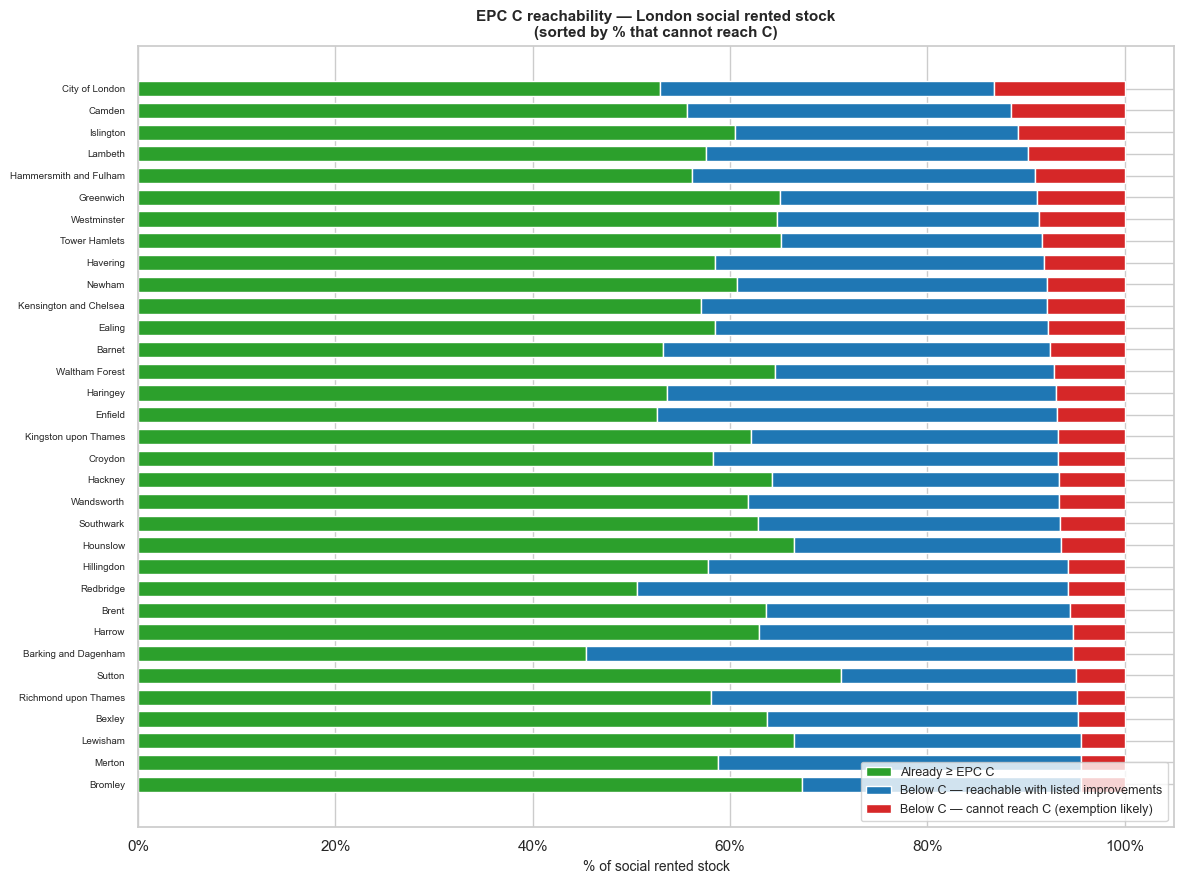

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

os.makedirs('../outputs', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')

can_reach_n    = prop[prop['epc_reachable']].groupby('borough').size()
cannot_reach_n = prop[~prop['epc_reachable']].groupby('borough').size()

reach = pd.DataFrame({
    'already_c':    already_c_n,
    'can_reach':    can_reach_n,
    'cannot_reach': cannot_reach_n,
}).fillna(0).astype(int)
reach['total'] = reach.sum(axis=1)
reach_pct = reach[['already_c', 'can_reach', 'cannot_reach']].div(reach['total'], axis=0) * 100
reach_pct = reach_pct.sort_values('cannot_reach', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
bottom = np.zeros(len(reach_pct))
for col, colour, label in [
    ('already_c',    '#2ca02c', 'Already ≥ EPC C'),
    ('can_reach',    '#1f77b4', 'Below C — reachable with listed improvements'),
    ('cannot_reach', '#d62728', 'Below C — cannot reach C (exemption likely)'),
]:
    ax.barh(reach_pct.index, reach_pct[col], left=bottom, color=colour, label=label, height=0.7)
    bottom += reach_pct[col].values

ax.set_xlabel('% of social rented stock', fontsize=10)
ax.set_title(
    'EPC C reachability — London social rented stock\n(sorted by % that cannot reach C)',
    fontweight='bold', fontsize=11,
)
ax.legend(loc='lower right', fontsize=9)
ax.tick_params(axis='y', labelsize=7)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('../outputs/08_reachability_by_borough.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 08_reachability_by_borough.png')

Saved 08_cost_per_epc_point.png


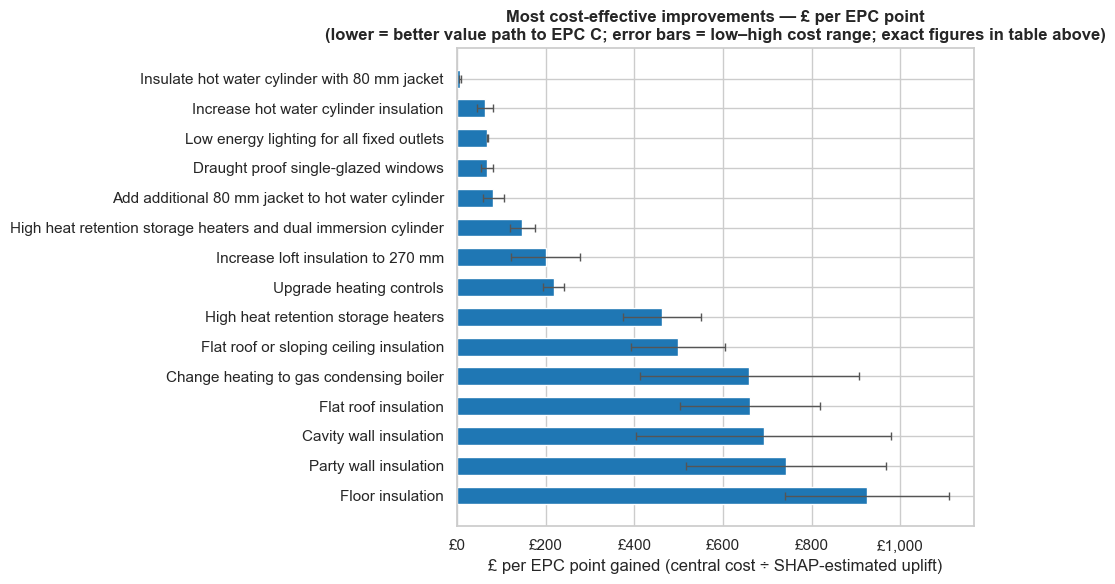

In [14]:
top_eff = (
    cost_eff.dropna(subset=['£_per_epc_point'])
    .sort_values('£_per_epc_point')
    .head(15)
).reset_index(drop=True)

xerr_lo = (top_eff['£_per_epc_point'] - top_eff['£_per_epc_point_low']).clip(lower=0)
xerr_hi = (top_eff['£_per_epc_point_high'] - top_eff['£_per_epc_point']).clip(lower=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_eff['improvement_type'], top_eff['£_per_epc_point'],
    xerr=[xerr_lo, xerr_hi],
    color='#1f77b4', height=0.6,
    error_kw=dict(ecolor='#555', capsize=3, lw=1),
)
ax.set_xlabel('£ per EPC point gained (central cost ÷ SHAP-estimated uplift)')
ax.set_title(
    'Most cost-effective improvements — £ per EPC point\n'
    '(lower = better value path to EPC C; error bars = low–high cost range; exact figures in table above)',
    fontweight='bold',
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/08_cost_per_epc_point.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 08_cost_per_epc_point.png')

Saved 08_age_band_analysis.png


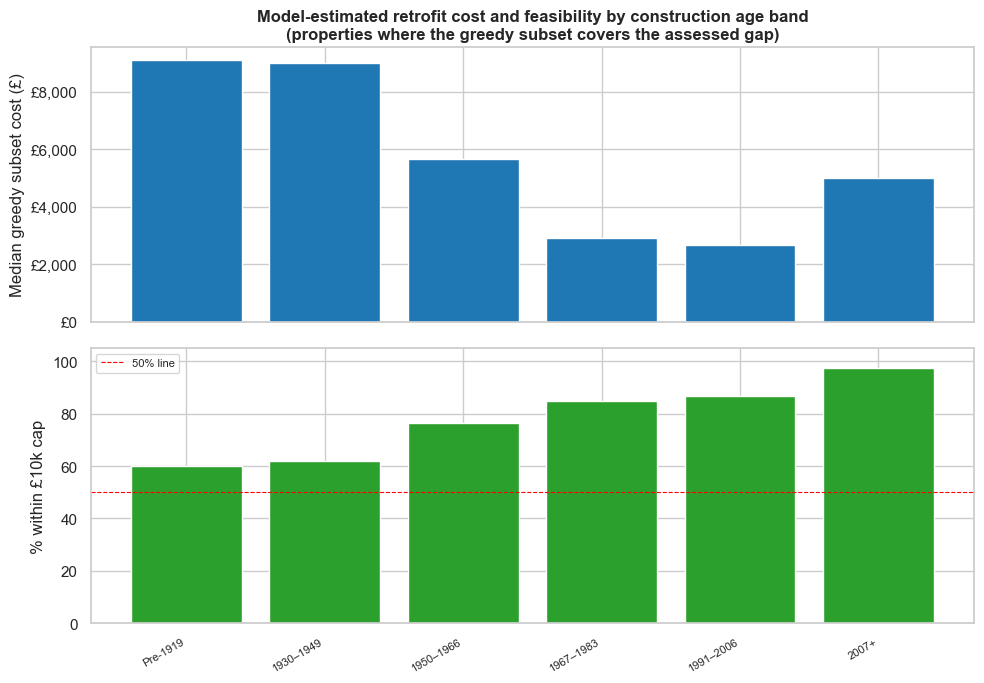

In [15]:
age_stats = (
    prop[prop['epc_reachable'] & prop['has_greedy']]
    .groupby('age_group')
    .agg(pct_within_10k=('greedy_cost_mid', lambda x: (x <= EXEMPT_CAP).mean()),
         median_cost_mid=('greedy_cost_mid', 'median'))
    .reindex(AGE_ORDER).dropna(how='all')
)
age_stats['pct_within_10k'] = age_stats['pct_within_10k'] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.bar(range(len(age_stats)), age_stats['median_cost_mid'], color='#1f77b4')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.set_ylabel('Median greedy subset cost (£)')
ax1.set_title(
    'Model-estimated retrofit cost and feasibility by construction age band\n(properties where the greedy subset covers the assessed gap)',
    fontweight='bold',
)

ax2.bar(range(len(age_stats)), age_stats['pct_within_10k'], color='#2ca02c')
ax2.axhline(50, color='red', linestyle='--', linewidth=0.8, label='50% line')
ax2.set_ylabel('% within £10k cap')
ax2.set_ylim(0, 105)
ax2.set_xticks(range(len(age_stats)))
ax2.set_xticklabels(age_stats.index, rotation=30, ha='right', fontsize=8)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/08_age_band_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 08_age_band_analysis.png')

## 9. Save outputs

In [16]:
import os
os.makedirs(f'{GOLD}/minimum_cost_to_c', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# SHAP uplift table + cost efficiency (the key novel finding)
shap_table.to_csv('../outputs/shap_uplift_by_age_group.csv', index=False)
print('Saved shap_uplift_by_age_group.csv')

cost_eff.to_csv('../outputs/rec_cost_efficiency.csv', index=False)
print('Saved rec_cost_efficiency.csv')

# Borough summary
borough.to_parquet(f'{GOLD}/minimum_cost_to_c/borough_greedy_cost.parquet', index=False)
borough.to_csv('../outputs/borough_greedy_cost.csv', index=False)
print('Saved borough_greedy_cost (Parquet + CSV)')

print('\nAll outputs saved.')

Saved shap_uplift_by_age_group.csv
Saved rec_cost_efficiency.csv
Saved borough_greedy_cost (Parquet + CSV)

All outputs saved.


## Summary of key findings

### Headline numbers (London social rented, EPC data)
- **195,204 below-C properties** identified across 33 boroughs (from **491,869** unique properties after UPRN dedup); **81.6% (159,202) are assessor-reachable** to C with listed recommendations.
- **Borough cost range is 3.3×:** median greedy subset cost £4,000 (Tower Hamlets) → £9,000 (Brent / Camden / Hackney). Brent, Camden, and Hackney are the highest-cost boroughs — Brent has 18.4% of reachable stock exceeding the £10k exemption cap.
- **Pre-1919 stock dominates the cost outliers**, reflecting the solid-wall insulation driver identified in notebook 07.
- **Top cost-effective measure:** hot water cylinder jacket at £6/EPC-point — **9× more cost-effective than the next best measure** (£55/pt). Draught-proofing single-glazed windows (£60/pt) and low-energy lighting (£62/pt) round out the quick wins.
- **~2.7 recommendations on average** are needed to move a below-C property to C (from the greedy cheapest-per-SHAP-point subset; the greedy successfully covers the assessed gap for ~55% of reachable properties).

### Method
- **RandomForest** predicts total achievable EPC uplift from recommendation presence + property characteristics (age, type, starting score).
- **SHAP** attributes each prediction back to individual features; stratifying by construction age band gives vintage-specific estimates.
- **Greedy selection** (cheapest SHAP-point first) produces model-estimated costs for the most cost-effective rec subset per property — covering ~55% of assessor-reachable stock. The remaining 46% have recommendations but rec-only SHAP values do not accumulate to cover the full assessed gap, a known limitation of applying SHAP to a holistic uplift prediction.

### Key outputs
| File | Contents |
|---|---|
| `shap_uplift_by_age_group.csv` | Per-rec SHAP uplift, overall + by age group |
| `rec_cost_efficiency.csv` | £/EPC-point cost-effectiveness ranking of rec types |
| `borough_greedy_cost.csv` | Median greedy cost per borough (low/central/high), % over £10k, avg recs to C |
| `08_reachability_by_borough.png` | Stacked bar: already C / can reach / cannot reach |
| `08_cost_per_epc_point.png` | Most cost-effective improvements by £/EPC-point (with cost range) |
| `08_age_band_analysis.png` | Retrofit cost and within-cap feasibility by building vintage |

### Interpretation caveat: fabric-measure SHAP values are underestimates

The SHAP figures for **cavity wall (£702/pt)** and **solid wall insulation (~£8,000/pt)** are **lower-bound estimates** of standalone physical uplift. Two reasons:

1. **Multicollinearity with construction age.** ~95% of solid-wall recommendations sit on pre-1919 stock. The model has `construction_age_band` as a separate feature. SHAP must apportion credit between the SWI flag and the age flag, which carry the same information — a well-known SHAP behaviour with correlated features. A large chunk of the effect ends up credited to age, not SWI.
2. **Flat vs house archetype.** ~60% of London social rented is flats. A mid-floor flat with party walls on 2+ sides has far less exposed external wall area than a detached house, so genuine physical uplift from SWI on a flat is 2–4 SAP points — not the 8–25 points often cited from house-weighted industry benchmarks.

**Practical implication:** the **ranking of quick-wins** (cylinder → draught-proofing → lighting) is reliable and consistent with RdSAP guidance. The **absolute per-point figures for structural measures** should be validated against RdSAP output for the specific archetype mix a housing association actually owns, not compared to generic web tables.

### Caveats
- Indicative costs are national RdSAP ranges — London labour rates typically run 15–30% above these.
- SHAP values are model-estimated associations, not direct observations of per-recommendation EPC uplift. They capture correlation between rec presence and total achievable uplift, controlled for property characteristics, but do not represent the standalone physical contribution of any individual measure.
- The greedy cost estimates apply to ~55% of assessor-reachable properties; they are indicative rankings, not guaranteed minimum costs to reach C.
- The EPC reachability flag (potential ≥ 69) is the assessor's professional judgement and is used as ground truth for whether C is achievable.